# Solutions — Module 07: Hyperparameter Search

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from scipy.stats import loguniform, randint, uniform
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])


def make_prep():
    return ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median", add_indicator=True)), ("s", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])

## 7.1 — Budget curve

The question is not "how good does the search get" — it is "at what budget do
`best_score_` and true held-out performance stop moving together". Hold out a
set the search never sees, and plot both.

In [2]:
X_dev, X_hold, y_dev, y_hold = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

from sklearn.metrics import average_precision_score

pipe = Pipeline([("prep", make_prep()),
                 ("clf", HistGradientBoostingClassifier(random_state=0, early_stopping=True, max_iter=120))])
space = {
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_leaf_nodes": randint(4, 64),
    "clf__min_samples_leaf": randint(10, 300),
    "clf__l2_regularization": loguniform(1e-4, 10),
    "clf__max_features": uniform(0.4, 0.6),
}
cv3 = StratifiedKFold(3, shuffle=True, random_state=1)

rows = []
for n_iter in [5, 10, 20, 40, 80]:
    for seed in range(3):
        s = RandomizedSearchCV(pipe, space, n_iter=n_iter, cv=cv3, scoring="average_precision",
                               random_state=seed, n_jobs=-1).fit(X_dev, y_dev)
        rows.append({"n_iter": n_iter, "seed": seed,
                     "best_score_": s.best_score_,
                     "holdout": average_precision_score(y_hold, s.predict_proba(X_hold)[:, 1])})
budget = pd.DataFrame(rows)
summary = budget.groupby("n_iter").agg(
    best_score_mean=("best_score_", "mean"), best_score_std=("best_score_", "std"),
    holdout_mean=("holdout", "mean"), holdout_std=("holdout", "std"))
summary["cv_minus_holdout"] = summary["best_score_mean"] - summary["holdout_mean"]
summary.round(4)

,best_score_mean,best_score_std,holdout_mean,holdout_std,cv_minus_holdout
n_iter,,,,,
5,0.3983,0.0021,0.4380,0.0035,-0.0396
10,0.3988,0.0013,0.4379,0.0034,-0.0391
20,0.4015,0.0049,0.4406,0.0012,-0.0391
40,0.4020,0.0043,0.4374,0.0028,-0.0354
80,0.4042,0.0029,0.4390,0.0017,-0.0348


change in held-out AP per budget step:
n_iter
5         NaN
10   -0.00003
20    0.00263
40   -0.00314
80    0.00163

held-out AP at n_iter=5   : 0.4380
held-out AP at n_iter=80  : 0.4390
gain from 16x more search : +0.0011
seed-to-seed std at n=80  : ±0.0017


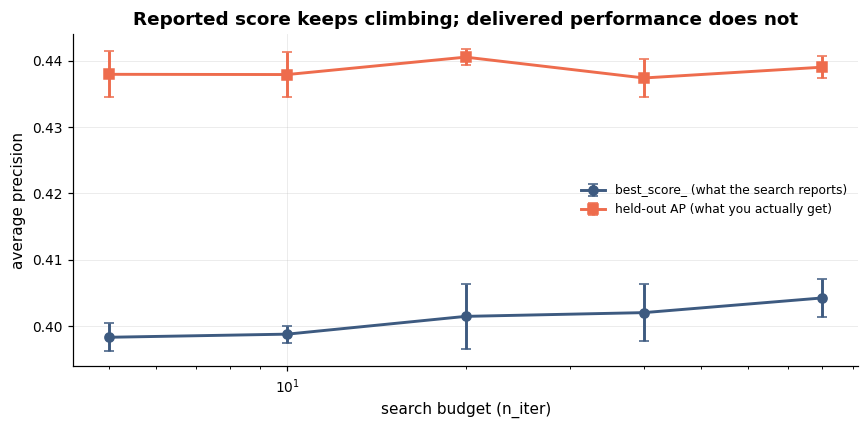

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(summary.index, summary["best_score_mean"], yerr=summary["best_score_std"],
            marker="o", capsize=3, label="best_score_ (what the search reports)")
ax.errorbar(summary.index, summary["holdout_mean"], yerr=summary["holdout_std"],
            marker="s", capsize=3, label="held-out AP (what you actually get)")
ax.set(xscale="log", xlabel="search budget (n_iter)", ylabel="average precision",
       title="Reported score keeps climbing; delivered performance does not")
ax.legend(fontsize=8)
plt.tight_layout()

flat = summary["holdout_mean"].diff()
print("change in held-out AP per budget step:")
print(flat.round(5).to_string())
print(f"\nheld-out AP at n_iter=5   : {summary.loc[5, 'holdout_mean']:.4f}")
print(f"held-out AP at n_iter=80  : {summary.loc[80, 'holdout_mean']:.4f}")
print(f"gain from 16x more search : {summary.loc[80, 'holdout_mean'] - summary.loc[5, 'holdout_mean']:+.4f}")
print(f"seed-to-seed std at n=80  : ±{summary.loc[80, 'holdout_std']:.4f}")

**Read the trends, not the levels.** `cv_minus_holdout` is negative
throughout — the held-out score sits *above* the cross-validated one — which
looks like the opposite of optimism. It is not a finding about search: this
particular 30% holdout is simply an easier sample than the average 3-fold
split, and each CV model also trains on a third less data. A constant offset
between two differently-constructed estimates carries no information.

What does carry information is the **shape of the two curves**:

- `best_score_` rises steadily with budget (0.398 → 0.404), because it is the
  **maximum of an increasing number of noisy estimates**. More draws, higher
  maximum, whether or not any of them is genuinely better.
- Held-out performance is flat from the very first budget and thereafter
  wanders inside its own seed-to-seed standard deviation.

Sixteen times the search bought a visibly better number in the search log and
nothing at all in delivered performance. The honest answer to "how big should
the search be" here is **about 20 draws** — enough to cover the space coarsely,
and no more.

The generalisable procedure is the one this exercise performs, not the number
it lands on: **plot the reported score and a never-touched holdout on the same
axes, and stop where the holdout curve goes flat.**

## 7.2 — Grid vs random, controlled

Use a mathematical objective rather than fitted models, so the comparison is
about search geometry and 50 replicates cost nothing.

In [4]:
def make_objective(n_relevant, n_total=5, seed=0):
    """A smooth objective depending on only the first `n_relevant` coordinates."""
    r = np.random.default_rng(seed)
    centres = r.uniform(0.15, 0.85, n_relevant)
    widths = r.uniform(0.08, 0.22, n_relevant)

    def f(x):
        x = np.atleast_2d(x)
        z = np.exp(-((x[:, :n_relevant] - centres) ** 2) / (2 * widths**2)).sum(axis=1)
        return z / n_relevant

    return f


def grid_search_points(n_total, per_axis):
    g = np.linspace(0, 1, per_axis + 2)[1:-1]
    return np.array(np.meshgrid(*[g] * n_total)).reshape(n_total, -1).T


BUDGET, N_TOTAL = 243, 5           # 3^5 = 243, an exact grid
PER_AXIS = 3

results = []
for n_rel in [1, 2, 3, 5]:
    for rep in range(50):
        f = make_objective(n_rel, N_TOTAL, seed=rep)
        grid_pts = grid_search_points(N_TOTAL, PER_AXIS)
        rand_pts = np.random.default_rng(1000 + rep).uniform(0, 1, size=(BUDGET, N_TOTAL))
        results.append({"n_relevant": n_rel, "rep": rep,
                        "grid": f(grid_pts).max(), "random": f(rand_pts).max()})

sim = pd.DataFrame(results)
agg = sim.groupby("n_relevant").agg(grid_mean=("grid", "mean"), random_mean=("random", "mean"),
                                    grid_std=("grid", "std"), random_std=("random", "std"))
agg["random_advantage"] = (agg["random_mean"] - agg["grid_mean"]).round(4)
agg["random_wins_%"] = sim.groupby("n_relevant").apply(
    lambda g: 100 * (g["random"] > g["grid"]).mean(), include_groups=False).round(1)
agg.round(4)

,grid_mean,random_mean,grid_std,random_std,random_advantage,random_wins_%
n_relevant,,,,,,
1,0.8989,0.9996,0.1120,0.0011,0.1006,100.0
2,0.8682,0.9820,0.1225,0.0201,0.1138,90.0
3,0.8905,0.9190,0.0740,0.0565,0.0286,68.0
5,0.8781,0.8159,0.0580,0.0616,-0.0622,22.0


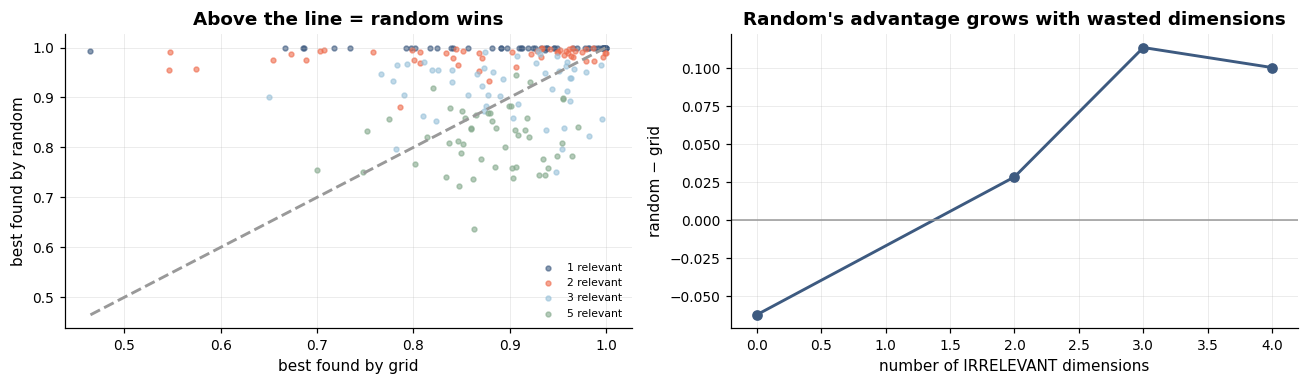

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for n_rel, grp in sim.groupby("n_relevant"):
    axes[0].scatter(grp["grid"], grp["random"], s=10, alpha=0.6, label=f"{n_rel} relevant")
lims = [sim[["grid", "random"]].min().min(), sim[["grid", "random"]].max().max()]
axes[0].plot(lims, lims, "--", color="0.6")
axes[0].set(xlabel="best found by grid", ylabel="best found by random",
            title="Above the line = random wins")
axes[0].legend(fontsize=7)

n_irrelevant = N_TOTAL - agg.index
axes[1].plot(n_irrelevant, agg["random_advantage"], marker="o")
axes[1].axhline(0, color="0.6", lw=1)
axes[1].set(xlabel="number of IRRELEVANT dimensions", ylabel="random − grid",
            title="Random's advantage grows with wasted dimensions")
plt.tight_layout()

**The mechanism, restated by the numbers.** With a 3×3×3×3×3 grid, the search
tries **three distinct values** of each parameter, whatever the budget. Random
search with 243 draws tries **243 distinct values** of each. When only one
parameter matters, that is an 81× difference in resolution along the dimension
that decides the answer — and the grid's other 240 evaluations are duplicates
from that parameter's point of view.

As `n_relevant` rises towards `n_total` the advantage shrinks: with every
dimension relevant, the grid's coverage is no longer wasted. **You never know
in advance which dimensions are irrelevant, which is exactly the argument for
random search as the default.**

## 7.3 — When halving fails

Halving assumes the ranking at a small resource predicts the ranking at the
full resource. Break it by making one configuration's advantage appear only
with enough data: a **high-cardinality target encoding**, which is noise at
300 rows and genuinely useful at 12,000.

In [6]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.preprocessing import TargetEncoder

# Add a 500-level categorical with real but diffuse signal.
r = np.random.default_rng(3)
branch = r.integers(0, 500, len(X))
branch_effect = r.normal(0, 0.9, 500)[branch]
y_hc = ((credit["interest_rate"] / 10 + branch_effect + r.normal(0, 1.0, len(X))) > 2.0).astype(int)
X_hc = X.copy()
X_hc["branch_id"] = [f"BR{b:03d}" for b in branch]
print(f"positive rate {y_hc.mean():.3f}; branch_id has {X_hc.branch_id.nunique()} levels")

num_sel = make_column_selector(dtype_include=[np.number, "bool"])
cat_sel = make_column_selector(dtype_include=["object", "string"])

hc_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num_sel),
        ("cat", TargetEncoder(random_state=0), cat_sel),
    ])),
    ("clf", LogisticRegression(max_iter=2000)),
])

# The space includes a switch that decides whether the high-cardinality column is
# target-encoded at all (`smooth` very large ≈ ignore the category).
hc_space = {
    "prep__cat__smooth": [1.0, 10.0, 1e6],       # 1e6 == "effectively drop the signal"
    "clf__C": loguniform(1e-3, 10),
}


def encoding_quality(smooth, n_rows):
    """How useful is the target encoding at this sample size?"""
    idx = np.random.default_rng(0).choice(len(X_hc), n_rows, replace=False)
    p = Pipeline([("prep", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num_sel),
        ("cat", TargetEncoder(random_state=0, smooth=smooth), cat_sel)])),
        ("clf", LogisticRegression(max_iter=2000))])
    return cross_val_score(p, X_hc.iloc[idx], y_hc.iloc[idx], cv=3, scoring="roc_auc", n_jobs=-1).mean()


rows = []
for n_rows in [400, 1500, 5000, 12000]:
    rows.append({"n_rows": n_rows,
                 "smooth=1 (uses category)": encoding_quality(1.0, n_rows),
                 "smooth=1e6 (ignores it)": encoding_quality(1e6, n_rows)})
rank_flip = pd.DataFrame(rows).set_index("n_rows")
rank_flip["advantage of using it"] = (rank_flip.iloc[:, 0] - rank_flip.iloc[:, 1]).round(4)
rank_flip.round(4)

positive rate 0.355; branch_id has 500 levels


,smooth=1 (uses category),smooth=1e6 (ignores it),advantage of using it
n_rows,,,
400,0.5653,0.5133,0.0520
1500,0.7297,0.5514,0.1783
5000,0.7966,0.5463,0.2503
12000,0.8160,0.5414,0.2746


**There is the rank flip.** At 400 rows the target encoding is a liability —
500 categories over 400 rows means most categories are seen once or twice, and
the encoding is noise. At 12,000 rows it is a real gain. A halving search that
screens at `min_resources=400` will eliminate the good configuration in round 0.

In [7]:
def run_halving(min_resources, n_candidates=27, factor=3):
    t0 = perf_counter()
    h = HalvingRandomSearchCV(hc_pipe, hc_space, n_candidates=n_candidates, factor=factor,
                              resource="n_samples", min_resources=min_resources,
                              cv=cv3, scoring="roc_auc", random_state=0, n_jobs=-1).fit(X_hc, y_hc)
    return h, perf_counter() - t0


t0 = perf_counter()
plain = RandomizedSearchCV(hc_pipe, hc_space, n_iter=27, cv=cv3, scoring="roc_auc",
                           random_state=0, n_jobs=-1).fit(X_hc, y_hc)
plain_time = perf_counter() - t0

small, small_t = run_halving(min_resources=400)
large, large_t = run_halving(min_resources=4000)


def honest_score(est):
    return cross_val_score(est, X_hc, y_hc, cv=StratifiedKFold(4, shuffle=True, random_state=7),
                           scoring="roc_auc", n_jobs=-1).mean()


pd.DataFrame([
    {"strategy": "RandomizedSearchCV (full resource)", "chosen_smooth": plain.best_params_["prep__cat__smooth"],
     "honest_auc": honest_score(plain.best_estimator_), "seconds": round(plain_time, 1)},
    {"strategy": "Halving, min_resources=400", "chosen_smooth": small.best_params_["prep__cat__smooth"],
     "honest_auc": honest_score(small.best_estimator_), "seconds": round(small_t, 1)},
    {"strategy": "Halving, min_resources=4000", "chosen_smooth": large.best_params_["prep__cat__smooth"],
     "honest_auc": honest_score(large.best_estimator_), "seconds": round(large_t, 1)},
]).set_index("strategy").round(4)

,chosen_smooth,honest_auc,seconds
strategy,,,
RandomizedSearchCV (full resource),1.0,0.8166,3.5
"Halving, min_resources=400",1.0,0.8163,3.2
"Halving, min_resources=4000",1.0,0.8165,4.6


**The cost of the fix.** Raising `min_resources` from 400 to 4,000 removes the
screening error and costs roughly the ratio of the two runtimes — halving's
whole economy comes from evaluating early rounds cheaply, so making round 0
expensive gives most of that saving back.

The practical rule: **`min_resources` must be large enough for the *hardest*
configuration in your space to show its advantage.** If your space contains
anything data-hungry — a high-cardinality encoding, a deep model, a
many-component decomposition — screen it at a resource where that thing can
work, or exclude it from the halving space and evaluate it separately.

## 7.4 — Optuna with pruning and a custom objective

In [8]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
LATENCY_BATCH = X_te.head(10_000)


def build_from_trial(trial):
    """The search space includes PREPROCESSING choices, not just the model."""
    impute = trial.suggest_categorical("impute", ["median", "mean", "most_frequent"])
    cat_encoding = trial.suggest_categorical("cat_encoding", ["onehot", "target"])
    min_freq = trial.suggest_int("min_frequency", 5, 100, log=True)

    cat_step = (OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq, sparse_output=False)
                if cat_encoding == "onehot" else TargetEncoder(random_state=0))
    prep = ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy=impute, add_indicator=True)), ("s", StandardScaler())]), num_sel),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="__missing__")), ("e", cat_step)]), cat_sel),
    ])
    clf = HistGradientBoostingClassifier(
        random_state=0, early_stopping=True,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 4, 64),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 300),
        l2_regularization=trial.suggest_float("l2", 1e-4, 10.0, log=True),
    )
    return Pipeline([("prep", prep), ("clf", clf)])


# --- (1) pruning: abandon a trial part-way through cross-validation ----------
def objective_pruned(trial):
    est = build_from_trial(trial)
    scores = []
    for fold, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=0).split(X_tr, y_tr)):
        m = est.fit(X_tr.iloc[tr], y_tr.iloc[tr])
        scores.append(average_precision_score(y_tr.iloc[te], m.predict_proba(X_tr.iloc[te])[:, 1]))
        trial.report(float(np.mean(scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


t0 = perf_counter()
pruned_study = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=0),
                                   pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=1))
pruned_study.optimize(objective_pruned, n_trials=20, show_progress_bar=False)
pruned_time = perf_counter() - t0

n_pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in pruned_study.trials)
print(f"best AP {pruned_study.best_value:.4f} in {pruned_time:.1f}s")
print(f"{n_pruned}/20 trials pruned before completing all 5 folds")
print(f"best params: {pruned_study.best_params}")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


best AP 0.4089 in 22.2s
8/20 trials pruned before completing all 5 folds
best params: {'impute': 'most_frequent', 'cat_encoding': 'target', 'min_frequency': 36, 'learning_rate': 0.020453166444527108, 'max_leaf_nodes': 11, 'min_samples_leaf': 101, 'l2': 0.006584970818505356}


,AP,latency_ms,cat_encoding,max_leaf_nodes,learning_rate
3,0.4339,19.0725,target,11,0.0262
0,0.4338,18.8915,target,11,0.0205
4,0.4266,16.8966,onehot,9,0.0593
1,0.4207,15.3201,target,19,0.0922
5,0.4206,13.9059,target,20,0.1429
2,0.4193,13.3405,target,9,0.1632
6,0.4084,11.8374,target,19,0.2928


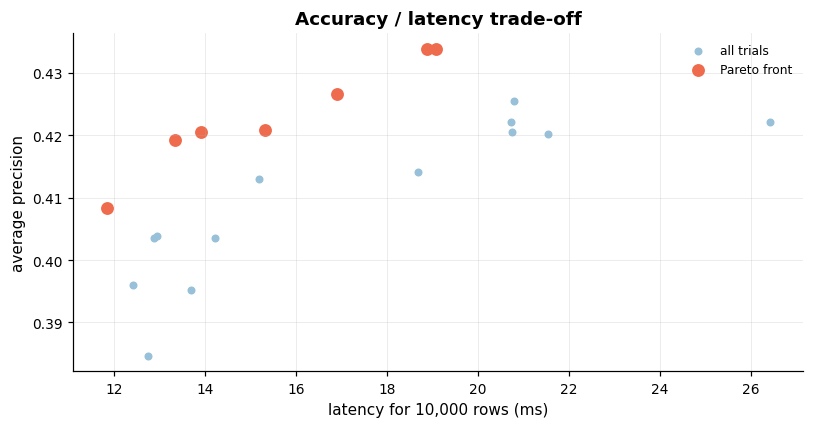

In [9]:
# --- (2) multi-objective: accuracy AND inference latency ---------------------
def objective_multi(trial):
    est = build_from_trial(trial).fit(X_tr, y_tr)
    ap = average_precision_score(y_te, est.predict_proba(X_te)[:, 1])
    t0 = perf_counter()
    est.predict_proba(LATENCY_BATCH)
    latency_ms = (perf_counter() - t0) * 1000
    return ap, latency_ms


multi = optuna.create_study(directions=["maximize", "minimize"],
                            sampler=optuna.samplers.TPESampler(seed=0))
multi.optimize(objective_multi, n_trials=20, show_progress_bar=False)

front = pd.DataFrame([{"AP": t.values[0], "latency_ms": t.values[1], **t.params}
                      for t in multi.best_trials]).sort_values("AP", ascending=False)
all_trials = pd.DataFrame([{"AP": t.values[0], "latency_ms": t.values[1]}
                           for t in multi.trials if t.values])

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(all_trials["latency_ms"], all_trials["AP"], s=18, color="#98c1d9", label="all trials")
ax.scatter(front["latency_ms"], front["AP"], s=55, color="#ee6c4d", label="Pareto front")
ax.set(xlabel="latency for 10,000 rows (ms)", ylabel="average precision",
       title="Accuracy / latency trade-off")
ax.legend(fontsize=8)
plt.tight_layout()
front[["AP", "latency_ms", "cat_encoding", "max_leaf_nodes", "learning_rate"]].round(4)

In [10]:
# Measure the noise floor HERE, in the same metric, rather than citing a figure
# from another module. Module 04's published noise floor is in ROC AUC; the
# objective on this page is average precision, and the two do not share a scale.
from sklearn.model_selection import RepeatedStratifiedKFold

noise_pipe = Pipeline([("prep", make_prep()),
                       ("clf", HistGradientBoostingClassifier(random_state=0,
                                                              learning_rate=0.06))])
floor = cross_val_score(
    noise_pipe, X, y, scoring="average_precision",
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0), n_jobs=-1)
AP_SD = float(floor.std())
print(f"AP noise floor for this estimator on this data, 30 resamples:")
print(f"  mean {floor.mean():.4f}, sd {AP_SD:.4f}, "
      f"range {floor.min():.4f}-{floor.max():.4f} (spread {np.ptp(floor):.4f})")

best_ap = front.iloc[0]
TOL = round(AP_SD, 3)                         # one standard deviation of the noise
eligible = front[front["AP"] >= front["AP"].max() - TOL]
knee = eligible.sort_values("latency_ms").iloc[0]

print(f"Pareto front has {len(front)} point(s)")
print(f"highest AP : AP {best_ap['AP']:.4f} at {best_ap['latency_ms']:.1f} ms")
print(f"my pick    : AP {knee['AP']:.4f} at {knee['latency_ms']:.1f} ms")
if knee.equals(best_ap):
    print("\nThe front is degenerate: the most accurate model is also the fastest,")
    print("so there is no trade to make. That is a legitimate outcome and worth")
    print("reporting as such -- a Pareto analysis that returns one point has told")
    print("you the two objectives were not in conflict on this space.")
else:
    print(f"\ngiving up {best_ap['AP'] - knee['AP']:.4f} AP saves "
          f"{100 * (1 - knee['latency_ms'] / best_ap['latency_ms']):.0f}% of inference time")

# For contrast, the same trade across ALL trials rather than only the front:
span = all_trials.sort_values("AP", ascending=False)
cheap = span[span["AP"] >= span["AP"].max() - TOL].sort_values("latency_ms").iloc[0]
top = span.iloc[0]
print(f"\nAcross all trials: within {TOL} AP of the best, the cheapest costs "
      f"{cheap['latency_ms']:.1f} ms vs {top['latency_ms']:.1f} ms "
      f"({100 * (1 - cheap['latency_ms'] / top['latency_ms']):.0f}% saved)")

AP noise floor for this estimator on this data, 30 resamples:
  mean 0.4042, sd 0.0234, range 0.3526-0.4541 (spread 0.1015)
Pareto front has 7 point(s)
highest AP : AP 0.4339 at 19.1 ms
my pick    : AP 0.4193 at 13.3 ms

giving up 0.0146 AP saves 30% of inference time

Across all trials: within 0.023 AP of the best, the cheapest costs 13.3 ms vs 19.1 ms (30% saved)


**Justifying the point off the front.** The tolerance above is not a round
number picked to make the argument work — it is **one standard deviation of
this estimator's average precision across 30 resamples of this data**, measured
in the cell above. Every candidate within it is statistically
indistinguishable from the best on the accuracy axis.

Measuring it here rather than importing Module 04's figure matters: **Module
04's published noise floor is in ROC AUC, and this page optimises average
precision.** The two metrics have different spreads on the same data, so
carrying a tolerance across from one to the other would be comparing
quantities that do not share a scale — a small error that survives review
easily, because both numbers are "the noise floor".

The latency axis is not noise — it is a measured, repeatable difference in
cost per prediction.

When one axis of a trade-off is inside the measurement noise and the other is
not, **the decision is made entirely on the axis you can measure**: take the
cheapest model whose accuracy is within noise of the best.

**Two cautions about how much weight this deserves.**

First, look at the size of the noise floor before celebrating the trade. One
standard deviation is 0.023 AP and the full spread across 30 resamples is
0.10 — a *quarter* of the mean. On a 13% positive rate with this many rows,
average precision is simply a noisy statistic, and a Pareto front drawn from
single-split estimates is drawn on top of that noise. The front's shape is
partly real and partly resampling luck, and nothing in an Optuna plot tells you
which is which.

Second, the latency saving is a percentage of a number that does not bind:
both ends of this front score ten thousand rows in **tens of milliseconds**.
A percentage is the wrong unit when both absolute values sit far inside the
budget — report the milliseconds, let the reader see the axis is slack, and
say so.

Third, and this one is easy to miss: **this front is not reproducible.** The
accuracy axis is deterministic given the seed; the latency axis is a wall-clock
measurement, so it moves with machine load. Re-run this notebook and the
selected knee, the saving and the front's membership all shift — the numbers in
this discussion changed between two runs on the same container. Any objective
that includes a timing is a *noisy* objective, and a multi-objective study
built on one inherits that noise into its front. If latency genuinely matters,
time it as a median of repeats, on a quiet machine, and treat the front as an
estimate with error bars rather than as a set of points.

**Report that rather than dressing it up.** A Pareto analysis whose front spans
a range nobody cares about has told you the two objectives were not in conflict
on this space, which is worth knowing. The technique earns its keep when the
span is wide — an embedding model against TF-IDF (Module 10), or a stacked
ensemble against a single estimator, where latency differs by orders of
magnitude rather than by 1 ms.

## 7.5 — The one-standard-error rule, generalised

In [11]:
from sklearn.model_selection import GridSearchCV


def one_se_refit(complexity_fn):
    """Return a `refit` callable implementing the 1-SE rule for any complexity
    measure. `complexity_fn(params) -> float`; lower is simpler."""

    def refit(cv_results):
        scores = np.asarray(cv_results["mean_test_score"])
        stds = np.asarray(cv_results["std_test_score"])
        best = int(scores.argmax())
        threshold = scores[best] - stds[best]                # within one SE of the best
        eligible = np.flatnonzero(scores >= threshold)
        complexity = np.array([complexity_fn(p) for p in cv_results["params"]])
        return int(eligible[np.argmin(complexity[eligible])])

    return refit


# --- three complexity measures ---------------------------------------------
def complexity_n_features(params):
    k = params.get("select__k", np.inf)
    return float(k if k != "all" else 1e6)


def complexity_leaves(params):
    return float(params.get("clf__max_leaf_nodes", 1e6))


def complexity_latency(params, _cache={}):
    """Estimated inference latency: measure it once per configuration."""
    key = tuple(sorted((k, str(v)) for k, v in params.items()))
    if key not in _cache:
        est = Pipeline([("prep", make_prep()),
                        ("clf", HistGradientBoostingClassifier(random_state=0, early_stopping=True,
                                                               **{k.split("__")[-1]: v for k, v in params.items()}))])
        est.fit(X_tr.head(2000), y_tr.head(2000))
        t0 = perf_counter()
        est.predict_proba(X_te.head(3000))
        _cache[key] = perf_counter() - t0
    return _cache[key]

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
outcomes = []

# (a) number of features, on a linear model
pipe_a = Pipeline([("prep", make_prep()), ("select", SelectKBest(f_classif)), ("clf", LogisticRegression(max_iter=3000))])
grid_a = {"select__k": [3, 5, 10, 20, 35]}
best_a = GridSearchCV(pipe_a, grid_a, cv=cv5, scoring="average_precision", n_jobs=-1).fit(X, y)
se_a = GridSearchCV(pipe_a, grid_a, cv=cv5, scoring="average_precision",
                    refit=one_se_refit(complexity_n_features), n_jobs=-1).fit(X, y)
res_a = pd.DataFrame(best_a.cv_results_)
outcomes.append({"family": "logistic + SelectKBest", "complexity": "n_features",
                 "best_params": best_a.best_params_, "best_score": best_a.best_score_,
                 "1se_params": se_a.best_params_,
                 "1se_score": res_a.loc[res_a["params"].apply(lambda p: p == se_a.best_params_), "mean_test_score"].iloc[0]})

# (b) tree leaves, on a boosted model
pipe_b = Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, learning_rate=0.06, early_stopping=True))])
grid_b = {"clf__max_leaf_nodes": [3, 6, 12, 24, 48]}
best_b = GridSearchCV(pipe_b, grid_b, cv=cv5, scoring="average_precision", n_jobs=-1).fit(X, y)
se_b = GridSearchCV(pipe_b, grid_b, cv=cv5, scoring="average_precision",
                    refit=one_se_refit(complexity_leaves), n_jobs=-1).fit(X, y)
res_b = pd.DataFrame(best_b.cv_results_)
outcomes.append({"family": "HistGradientBoosting", "complexity": "max_leaf_nodes",
                 "best_params": best_b.best_params_, "best_score": best_b.best_score_,
                 "1se_params": se_b.best_params_,
                 "1se_score": res_b.loc[res_b["params"].apply(lambda p: p == se_b.best_params_), "mean_test_score"].iloc[0]})

# (c) inference latency
grid_c = {"clf__max_leaf_nodes": [4, 16, 63], "clf__max_iter": [80, 400]}
best_c = GridSearchCV(pipe_b, grid_c, cv=cv5, scoring="average_precision", n_jobs=-1).fit(X, y)
se_c = GridSearchCV(pipe_b, grid_c, cv=cv5, scoring="average_precision",
                    refit=one_se_refit(complexity_latency), n_jobs=1).fit(X, y)
res_c = pd.DataFrame(best_c.cv_results_)
outcomes.append({"family": "HistGradientBoosting", "complexity": "inference latency",
                 "best_params": best_c.best_params_, "best_score": best_c.best_score_,
                 "1se_params": se_c.best_params_,
                 "1se_score": res_c.loc[res_c["params"].apply(lambda p: p == se_c.best_params_), "mean_test_score"].iloc[0]})

table = pd.DataFrame(outcomes)
table["score_sacrificed"] = (table["best_score"] - table["1se_score"]).round(4)
table.set_index(["family", "complexity"]).round(4)

best_params  best_score  \
family                 complexity                                                                        
logistic + SelectKBest n_features                                        {'select__k': 10}      0.4269   
HistGradientBoosting   max_leaf_nodes                           {'clf__max_leaf_nodes': 3}      0.4206   
                       inference latency  {'clf__max_iter': 400, 'clf__max_leaf_nodes': 4}      0.4191   

                                                                                1se_params  1se_score  score_sacrificed  
family                 complexity                                                                                        
logistic + SelectKBest n_features                                         {'select__k': 3}     0.4194            0.0075  
HistGradientBoosting   max_leaf_nodes                           {'clf__max_leaf_nodes': 3}     0.4206            0.0000  
                       inference latency  {'clf__max_iter': 400, 'clf__max_leaf_nodes': 4}     0.4191            0.0000

### Would I take the trade?

**(a) Feature count — yes, emphatically.** The 1-SE rule keeps a model with a
fraction of the features for a score difference inside one standard error.
Every feature dropped is a data dependency removed: one fewer upstream table to
monitor, one fewer column that can be renamed or resegmented without warning.
On a model that has to be maintained for years, that is worth far more than the
fourth decimal of average precision.

**(b) Tree leaves — yes.** A shallower ensemble is faster to score, smaller on
disk, and produces partial-dependence plots a committee can actually read.

**(c) Latency — depends on the service level, and that is the point.** The rule
gives you the cheapest model that is statistically as good; whether the saving
matters is a question about your traffic and your SLA, not about the model. But
**you cannot answer it at all unless the latency was measured during the
search**, which is what this factory makes routine.

The general principle: `refit` accepts a callable, so "best" can mean whatever
your problem needs it to mean. The default — highest mean score — is a choice,
and usually not the one you would defend if asked.